In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
data=pd.read_csv('diabetes_dataset_with_notes.csv')
data.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."


In [72]:
data=data.drop('clinical_notes',axis=1)
data.head()

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [73]:
Q1=data['bmi'].quantile(0.25)
Q3=data['bmi'].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
data_final=data[(data['bmi']>=lower_bound)&(data['bmi']<=upper_bound)]

In [74]:
x=data.drop('diabetes',axis=1)
y = data['diabetes']

In [75]:
data.isnull().sum()

,0
year,0
gender,0
age,0
location,0
race:AfricanAmerican,0
race:Asian,0
race:Caucasian,0
race:Hispanic,0
race:Other,0
hypertension,0


In [76]:
quant=[]
cat=[]
for i in  x.columns:
    # Check if the column data type is numeric
    if pd.api.types.is_numeric_dtype(x[i]) and len(x[i].unique())>15:
        quant.append(i)
    else:
        cat.append(i)

In [77]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [78]:
non_num = x.select_dtypes(exclude='number').columns.to_list()
non_num


['gender', 'location', 'smoking_history']

In [79]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in non_num:
    data[i]=le.fit_transform(data[i])

In [80]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='mean')
x[quant]=imputer.fit_transform(x[quant])


In [81]:
from sklearn.impute import SimpleImputer
imputer=SimpleImputer(strategy='most_frequent')
x[cat]=imputer.fit_transform(x[cat])

In [82]:
# from sklearn.preprocessing import StandardScaler
# ss=StandardScaler()
# x[quant]=ss.fit_transform(x[quant])

In [83]:
# from sklearn.preprocessing import MinMaxScaler
# mm=MinMaxScaler()
# x[quant]=mm.fit_transform(x[quant])

In [84]:
le = LabelEncoder()
for col in non_num:

    x[col] = le.fit_transform(x[col])

In [85]:
# Perform one-hot encoding for categorical features
# x = pd.get_dummies(x, columns=cat, drop_first=True)

<Axes: >

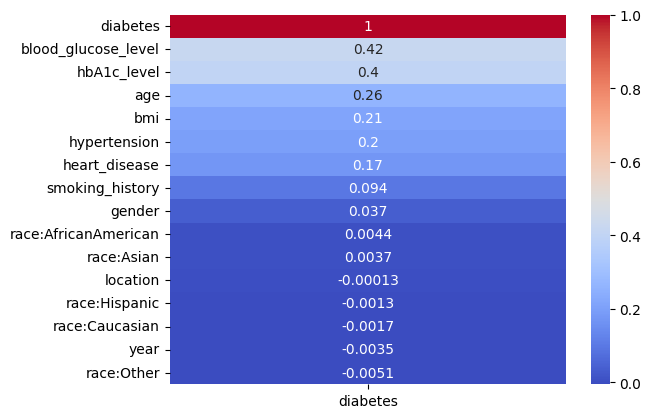

In [86]:
corr=data.corr()
labeled_corr=corr[['diabetes']].sort_values(by='diabetes',ascending=False)
sns.heatmap(labeled_corr,annot=True,cmap='coolwarm')

In [87]:
# Check if 'race:Asian' exists before attempting to drop it

x.drop('race:Asian', axis=1, inplace=True)

In [88]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [89]:
from imblearn.over_sampling import SMOTE

# Applying SMOTE
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

In [90]:
#naive bayes
from sklearn.naive_bayes import ComplementNB
nb = ComplementNB()
nb.fit(x_train, y_train)
y_pred = nb.predict(x_test)


In [91]:
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.8139
              precision    recall  f1-score   support

           0       0.97      0.82      0.89     18297
           1       0.28      0.72      0.40      1703

    accuracy                           0.81     20000
   macro avg       0.62      0.77      0.64     20000
weighted avg       0.91      0.81      0.85     20000



In [92]:
from sklearn.naive_bayes import CategoricalNB
nb = CategoricalNB()
nb.fit(x_train, y_train)
y_pred = nb.predict(x_test)

In [93]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.9173
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     18297
           1       0.51      0.81      0.63      1703

    accuracy                           0.92     20000
   macro avg       0.75      0.87      0.79     20000
weighted avg       0.94      0.92      0.93     20000



In [94]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(x_train, y_train)
y_pred = nb.predict(x_test)

In [95]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.8139
              precision    recall  f1-score   support

           0       0.97      0.82      0.89     18297
           1       0.28      0.72      0.40      1703

    accuracy                           0.81     20000
   macro avg       0.62      0.77      0.64     20000
weighted avg       0.91      0.81      0.85     20000



In [96]:
y_train.value_counts()

,count
diabetes,
0,73203
1,73203


In [97]:
#naive bayes
from sklearn.naive_bayes import ComplementNB
nb = ComplementNB()
nb.fit(x_train, y_train)
y_pred = nb.predict(x_test)


In [98]:
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.8139
              precision    recall  f1-score   support

           0       0.97      0.82      0.89     18297
           1       0.28      0.72      0.40      1703

    accuracy                           0.81     20000
   macro avg       0.62      0.77      0.64     20000
weighted avg       0.91      0.81      0.85     20000

